In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

In [42]:
soccer_scores = pd.read_csv('../output/csvs/soccer_projII.csv')
soccer_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.269036
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,5.714286
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.422475
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.103753
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.469136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.731343
1434,1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.008065
1435,1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.290123
1436,1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.703578


In [43]:
soccer_scores['League'] = soccer_scores['League'].replace("E0", "Premier_League")
soccer_scores['League'] = soccer_scores['League'].replace("D1", "Bundesliga")
soccer_scores['League'] = soccer_scores['League'].replace("SP1", "La_Liga")

In [44]:
soccer_scores['Team_Name'] = soccer_scores['Season'].astype(str) + ' ' + soccer_scores['Team']
soccer_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,Team_Name
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.269036,2000 Bayern Munich
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,5.714286,2000 Bochum
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.422475,2000 Cottbus
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.103753,2000 Dortmund
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.469136,2000 Ein Frankfurt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.731343,2024 Sociedad
1434,1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.008065,2024 Valencia
1435,1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.290123,2024 Valladolid
1436,1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.703578,2024 Vallecano


In [45]:
us_league_scores = pd.read_csv('../output/csvs/us_leagues_projII.csv')
us_league_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3
0,0,NBA,2015,Orlando Magic,"[0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...",82,41,41,35,20,15,3.764011,7.567749,5.494505
1,1,NBA,2015,Houston Rockets,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...",82,41,41,41,21,20,2.000000,2.423658,1.934236
2,2,NBA,2015,Oklahoma City Thunder,"[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, ...",82,41,41,55,29,26,2.749747,4.159434,3.030303
3,3,NBA,2015,Sacramento Kings,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,18,15,2.639310,4.005520,3.030303
4,4,NBA,2015,Utah Jazz,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, ...",82,41,41,40,18,22,1.277825,1.232172,1.172333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4318,4318,NBA,1982,Indiana Pacers,"[1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...",82,41,41,20,13,7,5.464184,16.280440,9.803922
4319,4319,NBA,1982,Washington Bullets,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",82,41,41,42,18,24,1.158671,1.101917,1.057082
4320,4320,NBA,1982,Dallas Mavericks,"[1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, ...",82,41,41,38,19,19,1.774389,2.000000,1.672241
4321,4321,NBA,1982,Denver Nuggets,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,45,19,26,1.115894,1.064008,1.041667


# 1. Most extreme Collapses

## Soccer League

In [46]:
soccer_scores['log_c1'] = np.log(soccer_scores['c1'])
soccer_scores['log_c2'] = np.log(soccer_scores['c2'])
soccer_scores['log_c3'] = np.log(soccer_scores['c3'])

soccer_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,Team_Name,log_c1,log_c2,log_c3
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.269036,2000 Bayern Munich,0.346570,0.419869,0.238257
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,5.714286,2000 Bochum,1.268947,2.351616,1.742969
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.422475,2000 Cottbus,0.431849,0.585585,0.352398
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.103753,2000 Dortmund,0.199821,0.214727,0.098716
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.469136,2000 Ein Frankfurt,0.823455,1.351674,0.903868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.731343,2024 Sociedad,1.064602,1.750629,1.316768
1434,1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.008065,2024 Valencia,0.030838,0.014233,0.008032
1435,1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.290123,2024 Valladolid,2.127773,4.097124,2.959593
1436,1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.703578,2024 Vallecano,0.583902,0.858610,0.532730


In [47]:
top20_c1 = soccer_scores.nlargest(20, "log_c1")[["Season", "League", "Team_Name", "log_c1"]]
top20_c2 = soccer_scores.nlargest(20, "log_c2")[["Season", "League", "Team_Name", "log_c2"]]
top20_c3 = soccer_scores.nlargest(20, "log_c3")[["Season", "League", "Team_Name", "log_c3"]]

top20_c1

,Season,League,Team_Name,log_c1
356,2019,Bundesliga,2019 Schalke 04,3.633475
1240,2015,La_Liga,2015 Eibar,3.111365
292,2016,Bundesliga,2016 Ein Frankfurt,3.022601
755,2015,Premier_League,2015 Crystal Palace,2.903254
1376,2021,La_Liga,2021 Vallecano,2.903254
1121,2009,La_Liga,2009 La Coruna,2.894519
1080,2007,La_Liga,2007 Espanol,2.736068
618,2008,Premier_League,2008 Hull,2.700427
868,2020,Premier_League,2020 Southampton,2.678658
172,2009,Bundesliga,2009 Leverkusen,2.549421


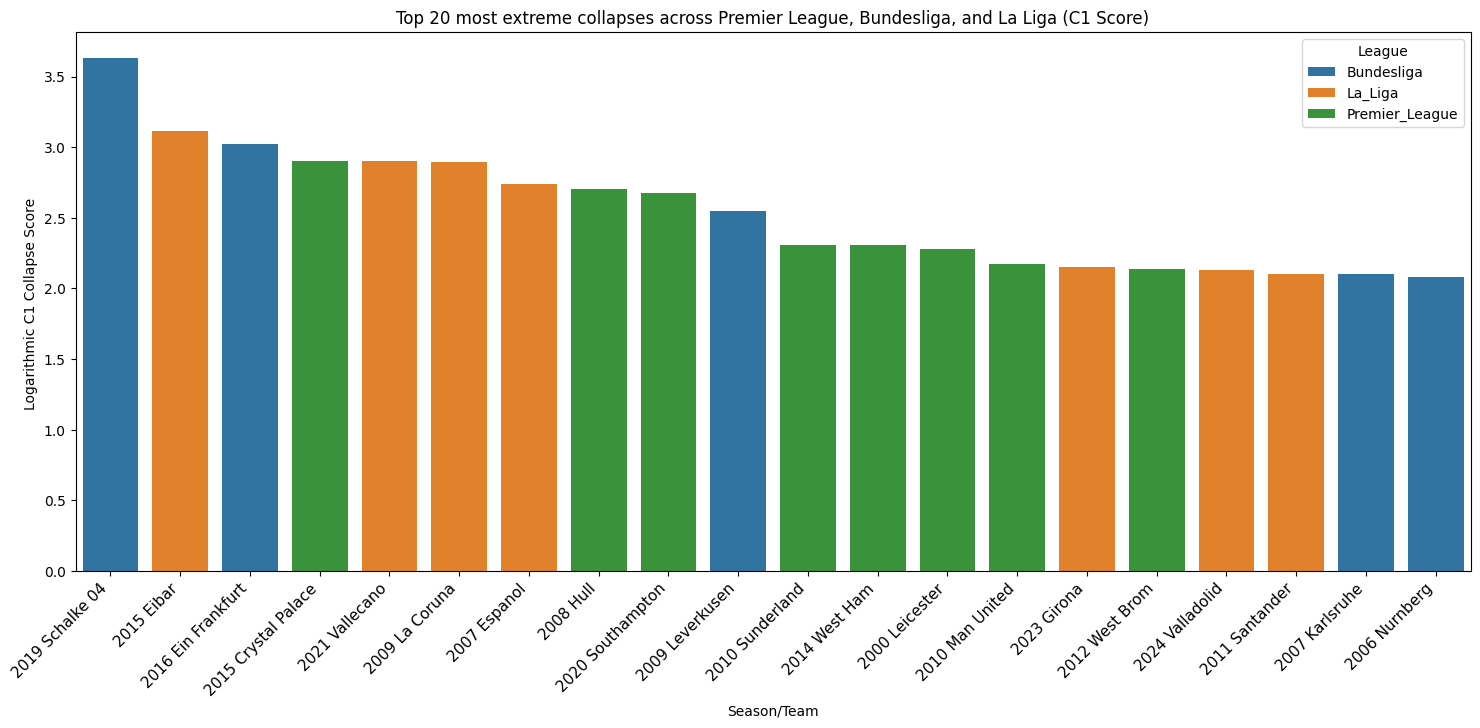

In [48]:
plt.figure(figsize=(18,7))

sns.barplot(x=top20_c1['Team_Name'], y = top20_c1['log_c1'], palette = 'tab10', hue = top20_c1['League'])
plt.title('Top 20 most extreme collapses across Premier League, Bundesliga, and La Liga (C1 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C1 Collapse Score ')
plt.xticks(rotation=45, fontsize=11, ha='right')  
plt.show()

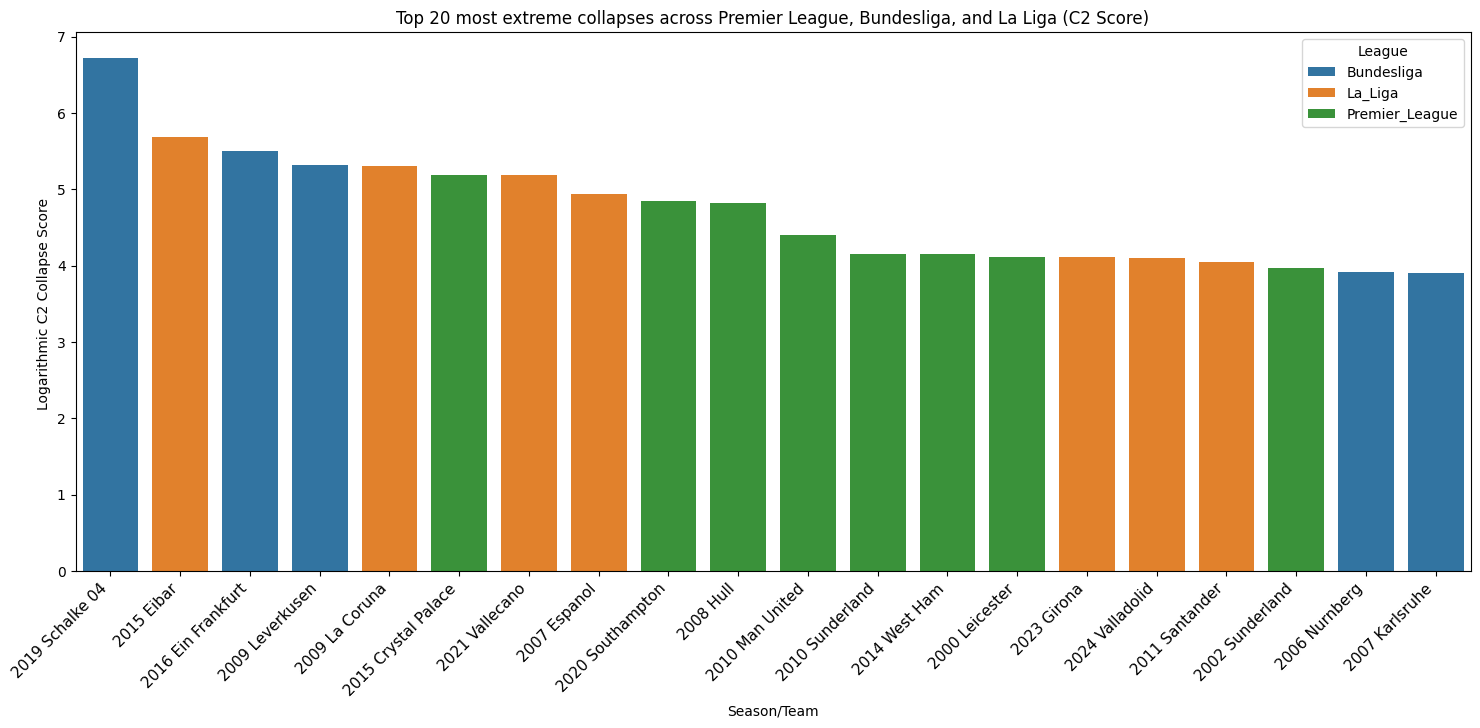

In [49]:
plt.figure(figsize=(18,7))

sns.barplot(x=top20_c2['Team_Name'], y = top20_c2['log_c2'], palette = 'tab10', hue = top20_c2['League'])
plt.title('Top 20 most extreme collapses across Premier League, Bundesliga, and La Liga (C2 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C2 Collapse Score ')
plt.xticks(rotation=45, fontsize=11, ha='right') 
plt.show()

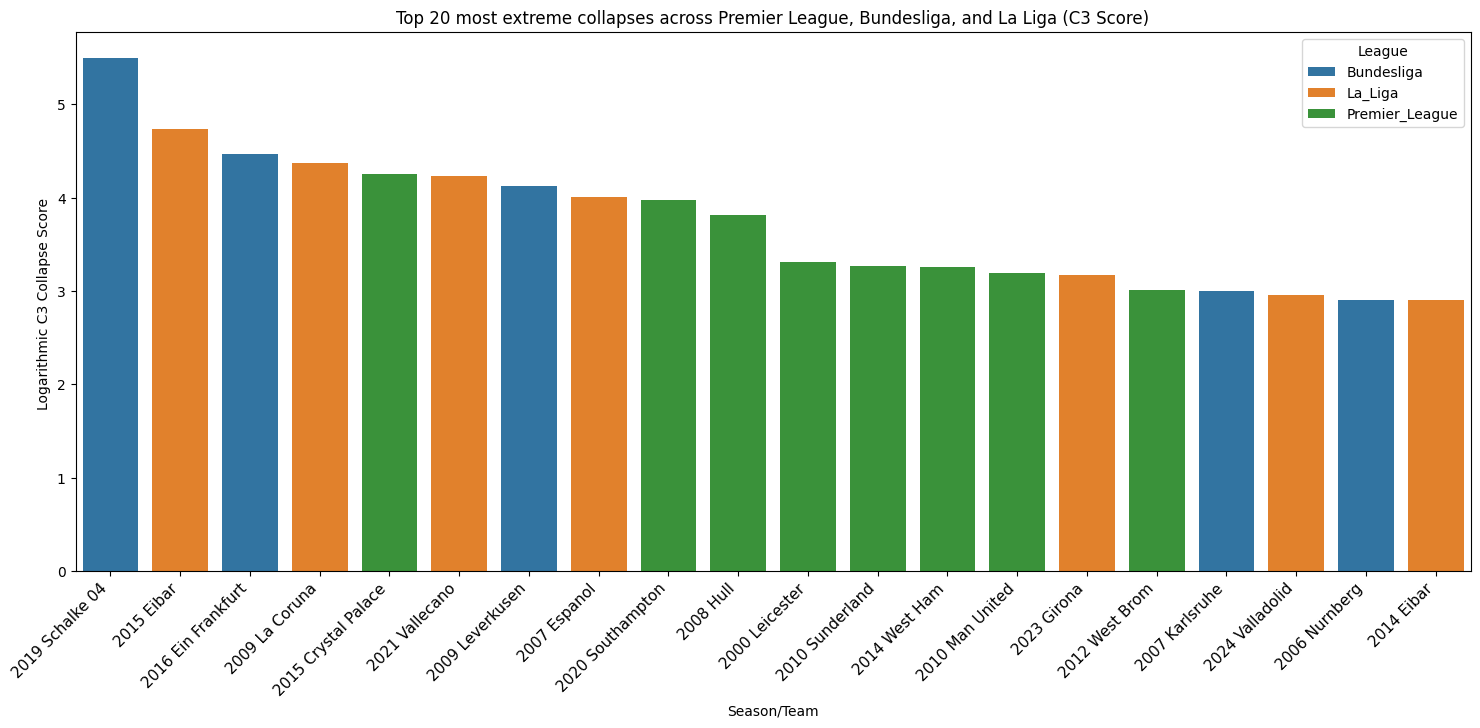

In [50]:
plt.figure(figsize=(18,7))

sns.barplot(x=top20_c3['Team_Name'], y = top20_c3['log_c3'], palette = 'tab10', hue = top20_c3['League'])
plt.title('Top 20 most extreme collapses across Premier League, Bundesliga, and La Liga (C3 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C3 Collapse Score ')
plt.xticks(rotation=45, fontsize=11, ha='right') 
plt.show()

## US Leagues

In [51]:
us_league_scores['log_c1'] = us_league_scores.apply(lambda row: math.log(row['c1']), axis  = 1)
us_league_scores['log_c2'] = us_league_scores.apply(lambda row: math.log(row['c2']), axis  = 1)
us_league_scores['log_c3'] = us_league_scores.apply(lambda row: math.log(row['c3']), axis  = 1)

us_league_scores['formatted_team_name'] = us_league_scores.apply(lambda row: str(row['Season']) + ' ' + row['Team'], axis = 1)

us_league_scores['color'] = us_league_scores.apply(lambda row: "orange" if row['League'] == 'NBA' else 'blue', axis = 1)

In [52]:
us_league_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,log_c1,log_c2,log_c3,formatted_team_name,color
0,0,NBA,2015,Orlando Magic,"[0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...",82,41,41,35,20,15,3.764011,7.567749,5.494505,1.325485,2.023896,1.703749,2015 Orlando Magic,orange
1,1,NBA,2015,Houston Rockets,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...",82,41,41,41,21,20,2.000000,2.423658,1.934236,0.693147,0.885278,0.659712,2015 Houston Rockets,orange
2,2,NBA,2015,Oklahoma City Thunder,"[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, ...",82,41,41,55,29,26,2.749747,4.159434,3.030303,1.011509,1.425379,1.108663,2015 Oklahoma City Thunder,orange
3,3,NBA,2015,Sacramento Kings,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,18,15,2.639310,4.005520,3.030303,0.970518,1.387673,1.108663,2015 Sacramento Kings,orange
4,4,NBA,2015,Utah Jazz,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, ...",82,41,41,40,18,22,1.277825,1.232172,1.172333,0.245159,0.208778,0.158996,2015 Utah Jazz,orange
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4318,4318,NBA,1982,Indiana Pacers,"[1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...",82,41,41,20,13,7,5.464184,16.280440,9.803922,1.698215,2.789964,2.282782,1982 Indiana Pacers,orange
4319,4319,NBA,1982,Washington Bullets,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",82,41,41,42,18,24,1.158671,1.101917,1.057082,0.147274,0.097051,0.055513,1982 Washington Bullets,orange
4320,4320,NBA,1982,Dallas Mavericks,"[1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, ...",82,41,41,38,19,19,1.774389,2.000000,1.672241,0.573456,0.693147,0.514165,1982 Dallas Mavericks,orange
4321,4321,NBA,1982,Denver Nuggets,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,45,19,26,1.115894,1.064008,1.041667,0.109655,0.062043,0.040822,1982 Denver Nuggets,orange


In [53]:
us_top20_c1 = us_league_scores.nlargest(20, "log_c1")[["Season", "League", "formatted_team_name", "log_c1"]]
us_top20_c2 = us_league_scores.nlargest(20, "log_c2")[["Season", "League", "formatted_team_name", "log_c2"]]
us_top20_c3 = us_league_scores.nlargest(20, "log_c3")[["Season", "League", "formatted_team_name", "log_c3"]]

us_top20_c1

,Season,League,formatted_team_name,log_c1
312,1943,MLB,1943 Philadelphia Athletics,4.474926
945,1977,MLB,1977 Chicago Cubs,4.356189
2842,2010,NBA,2010 Utah Jazz,4.319258
413,1949,MLB,1949 Washington Senators,4.096913
3742,1975,NBA,1975 Atlanta Hawks,3.841860
4154,1975,NBA,1975 Atlanta Hawks,3.841860
1691,2004,MLB,2004 Milwaukee Brewers,3.832378
1735,2005,MLB,2005 Washington Nationals,3.798058
849,1973,MLB,1973 Chicago Cubs,3.715958
904,1975,MLB,1975 Milwaukee Brewers,3.633267


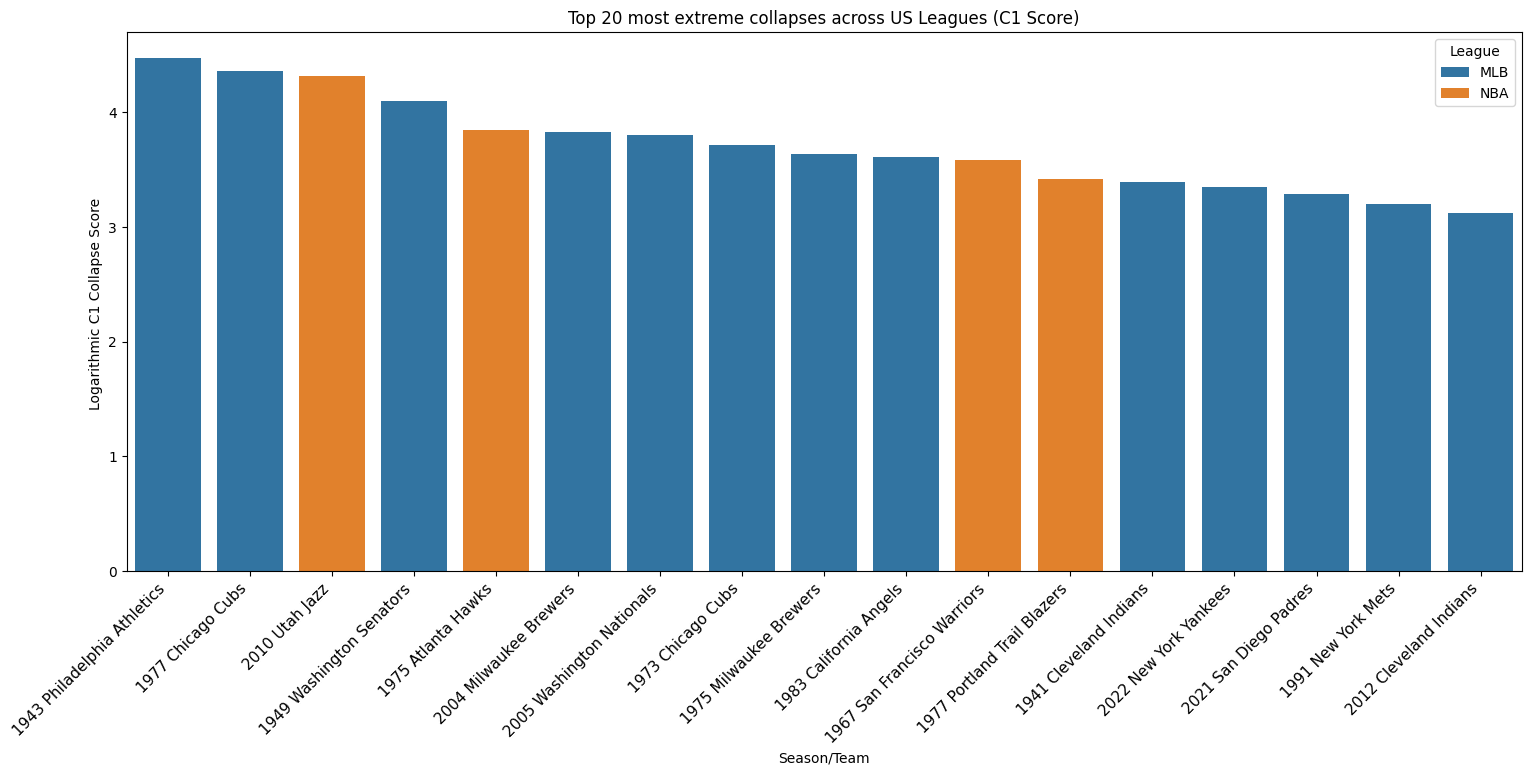

In [54]:
plt.figure(figsize=(18,7))

sns.barplot(x=us_top20_c1['formatted_team_name'], y = us_top20_c1['log_c1'], palette = 'tab10', hue = us_top20_c1['League'])
plt.title('Top 20 most extreme collapses across US Leagues (C1 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C1 Collapse Score ')
plt.xticks(rotation=45, fontsize=11, ha='right') 
plt.show()

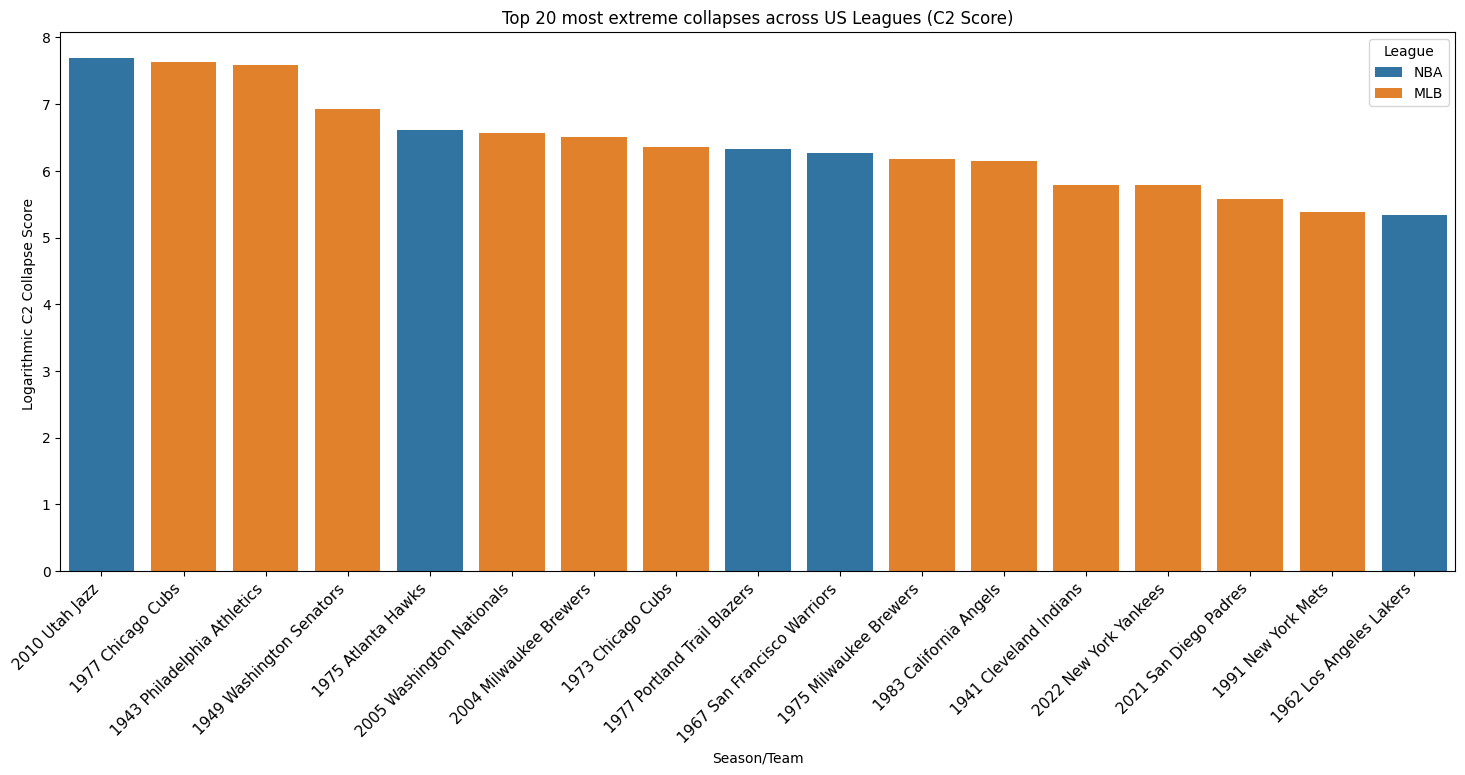

In [55]:
plt.figure(figsize=(18,7))

sns.barplot(x=us_top20_c2['formatted_team_name'], y = us_top20_c2['log_c2'], palette = 'tab10', hue = us_top20_c2['League'])
plt.title('Top 20 most extreme collapses across US Leagues (C2 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C2 Collapse Score ')
plt.xticks(rotation=45, fontsize=11, ha='right') 
plt.show()

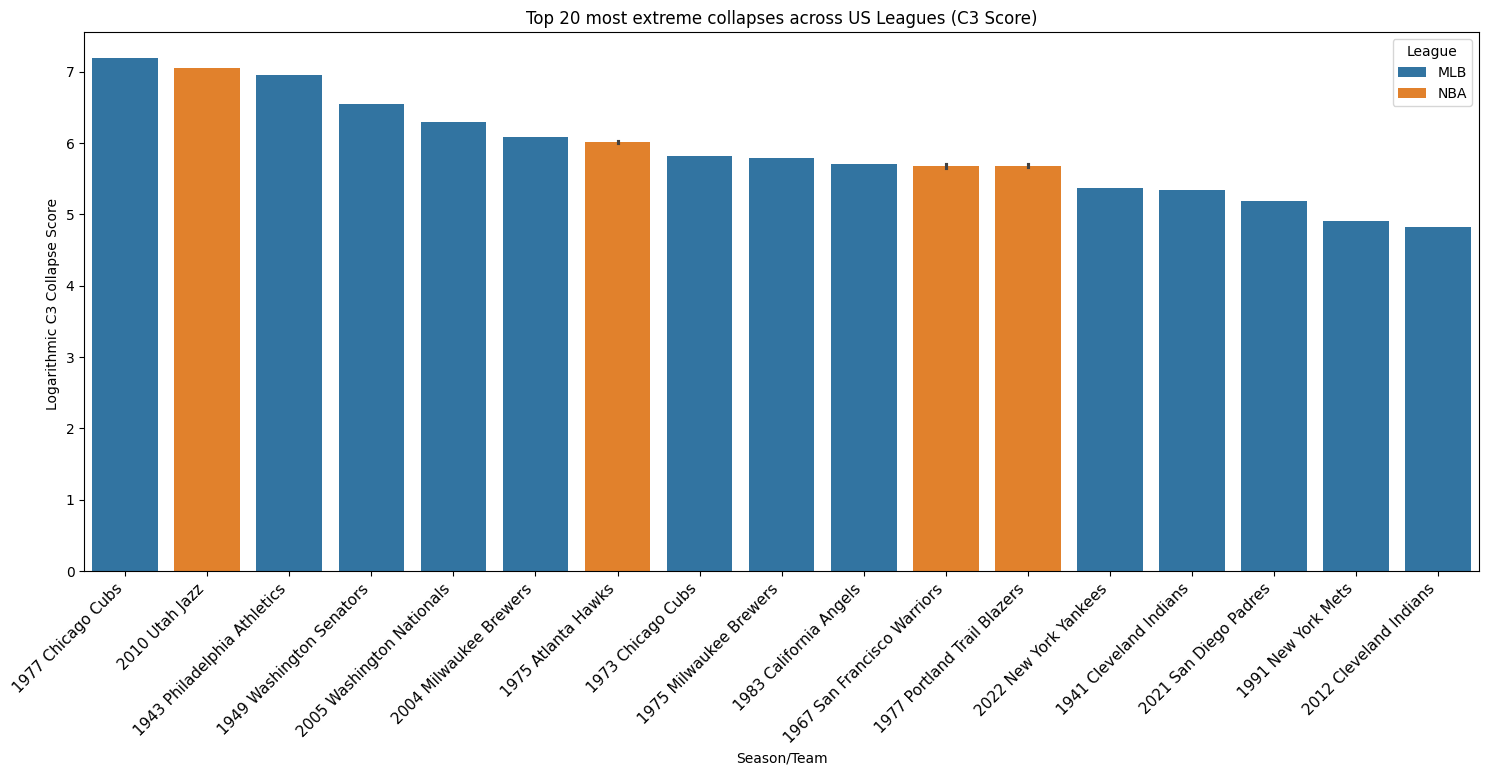

In [56]:
plt.figure(figsize=(18,7))

sns.barplot(x=us_top20_c3['formatted_team_name'], y = us_top20_c3['log_c3'], palette = 'tab10', hue = us_top20_c3['League'])
plt.title('Top 20 most extreme collapses across US Leagues (C3 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C3 Collapse Score ')
plt.xticks(rotation=45, fontsize=11, ha='right') 
plt.show()

## US Leagues and Soccer Leagues Combined

In [57]:
soccer_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,Team_Name,log_c1,log_c2,log_c3
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.269036,2000 Bayern Munich,0.346570,0.419869,0.238257
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,5.714286,2000 Bochum,1.268947,2.351616,1.742969
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.422475,2000 Cottbus,0.431849,0.585585,0.352398
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.103753,2000 Dortmund,0.199821,0.214727,0.098716
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.469136,2000 Ein Frankfurt,0.823455,1.351674,0.903868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.731343,2024 Sociedad,1.064602,1.750629,1.316768
1434,1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.008065,2024 Valencia,0.030838,0.014233,0.008032
1435,1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.290123,2024 Valladolid,2.127773,4.097124,2.959593
1436,1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.703578,2024 Vallecano,0.583902,0.858610,0.532730


In [58]:
us_league_scores['Team_Name'] = us_league_scores['formatted_team_name']

In [59]:
us_league_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,log_c1,log_c2,log_c3,formatted_team_name,color,Team_Name
0,0,NBA,2015,Orlando Magic,"[0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...",82,41,41,35,20,15,3.764011,7.567749,5.494505,1.325485,2.023896,1.703749,2015 Orlando Magic,orange,2015 Orlando Magic
1,1,NBA,2015,Houston Rockets,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...",82,41,41,41,21,20,2.000000,2.423658,1.934236,0.693147,0.885278,0.659712,2015 Houston Rockets,orange,2015 Houston Rockets
2,2,NBA,2015,Oklahoma City Thunder,"[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, ...",82,41,41,55,29,26,2.749747,4.159434,3.030303,1.011509,1.425379,1.108663,2015 Oklahoma City Thunder,orange,2015 Oklahoma City Thunder
3,3,NBA,2015,Sacramento Kings,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,18,15,2.639310,4.005520,3.030303,0.970518,1.387673,1.108663,2015 Sacramento Kings,orange,2015 Sacramento Kings
4,4,NBA,2015,Utah Jazz,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, ...",82,41,41,40,18,22,1.277825,1.232172,1.172333,0.245159,0.208778,0.158996,2015 Utah Jazz,orange,2015 Utah Jazz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4318,4318,NBA,1982,Indiana Pacers,"[1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...",82,41,41,20,13,7,5.464184,16.280440,9.803922,1.698215,2.789964,2.282782,1982 Indiana Pacers,orange,1982 Indiana Pacers
4319,4319,NBA,1982,Washington Bullets,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",82,41,41,42,18,24,1.158671,1.101917,1.057082,0.147274,0.097051,0.055513,1982 Washington Bullets,orange,1982 Washington Bullets
4320,4320,NBA,1982,Dallas Mavericks,"[1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, ...",82,41,41,38,19,19,1.774389,2.000000,1.672241,0.573456,0.693147,0.514165,1982 Dallas Mavericks,orange,1982 Dallas Mavericks
4321,4321,NBA,1982,Denver Nuggets,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,45,19,26,1.115894,1.064008,1.041667,0.109655,0.062043,0.040822,1982 Denver Nuggets,orange,1982 Denver Nuggets


In [60]:
combined_df = pd.concat([soccer_scores, us_league_scores], ignore_index=True)
combined_df

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,Team_Name,log_c1,log_c2,log_c3,formatted_team_name,color
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.269036,2000 Bayern Munich,0.346570,0.419869,0.238257,NaN,NaN
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,5.714286,2000 Bochum,1.268947,2.351616,1.742969,NaN,NaN
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.422475,2000 Cottbus,0.431849,0.585585,0.352398,NaN,NaN
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.103753,2000 Dortmund,0.199821,0.214727,0.098716,NaN,NaN
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.469136,2000 Ein Frankfurt,0.823455,1.351674,0.903868,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5756,4318,NBA,1982,Indiana Pacers,"[1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...",82,41,41,20,13,7,5.464184,16.280440,9.803922,1982 Indiana Pacers,1.698215,2.789964,2.282782,1982 Indiana Pacers,orange
5757,4319,NBA,1982,Washington Bullets,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",82,41,41,42,18,24,1.158671,1.101917,1.057082,1982 Washington Bullets,0.147274,0.097051,0.055513,1982 Washington Bullets,orange
5758,4320,NBA,1982,Dallas Mavericks,"[1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, ...",82,41,41,38,19,19,1.774389,2.000000,1.672241,1982 Dallas Mavericks,0.573456,0.693147,0.514165,1982 Dallas Mavericks,orange
5759,4321,NBA,1982,Denver Nuggets,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,45,19,26,1.115894,1.064008,1.041667,1982 Denver Nuggets,0.109655,0.062043,0.040822,1982 Denver Nuggets,orange


In [61]:
combined__top20_c1 = combined_df.nlargest(20, "log_c1")[["Season", "League", "Team_Name", "log_c1"]]
combined__top20_c2 = combined_df.nlargest(20, "log_c2")[["Season", "League", "Team_Name", "log_c2"]]
combined__top20_c3 = combined_df.nlargest(20, "log_c3")[["Season", "League", "Team_Name", "log_c3"]]

combined__top20_c1

,Season,League,Team_Name,log_c1
1750,1943,MLB,1943 Philadelphia Athletics,4.474926
2383,1977,MLB,1977 Chicago Cubs,4.356189
4280,2010,NBA,2010 Utah Jazz,4.319258
1851,1949,MLB,1949 Washington Senators,4.096913
5180,1975,NBA,1975 Atlanta Hawks,3.841860
5592,1975,NBA,1975 Atlanta Hawks,3.841860
3129,2004,MLB,2004 Milwaukee Brewers,3.832378
3173,2005,MLB,2005 Washington Nationals,3.798058
2287,1973,MLB,1973 Chicago Cubs,3.715958
356,2019,Bundesliga,2019 Schalke 04,3.633475


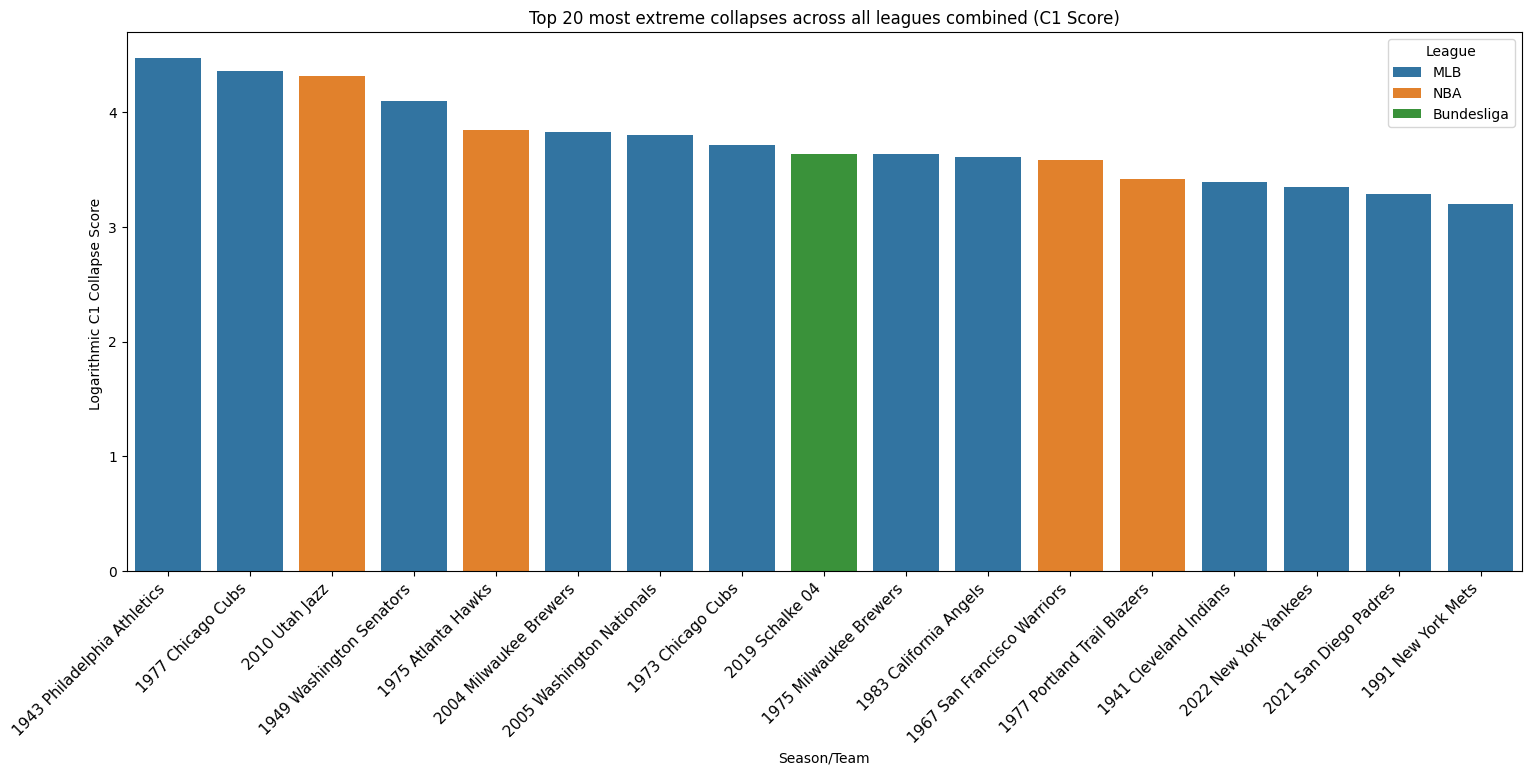

In [62]:
plt.figure(figsize=(18,7))

sns.barplot(x=combined__top20_c1['Team_Name'], y = combined__top20_c1['log_c1'], palette = 'tab10', hue = combined__top20_c1['League'])
plt.title('Top 20 most extreme collapses across all leagues combined (C1 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C1 Collapse Score ')
plt.xticks(rotation=45, fontsize=11, ha='right') 
plt.show()

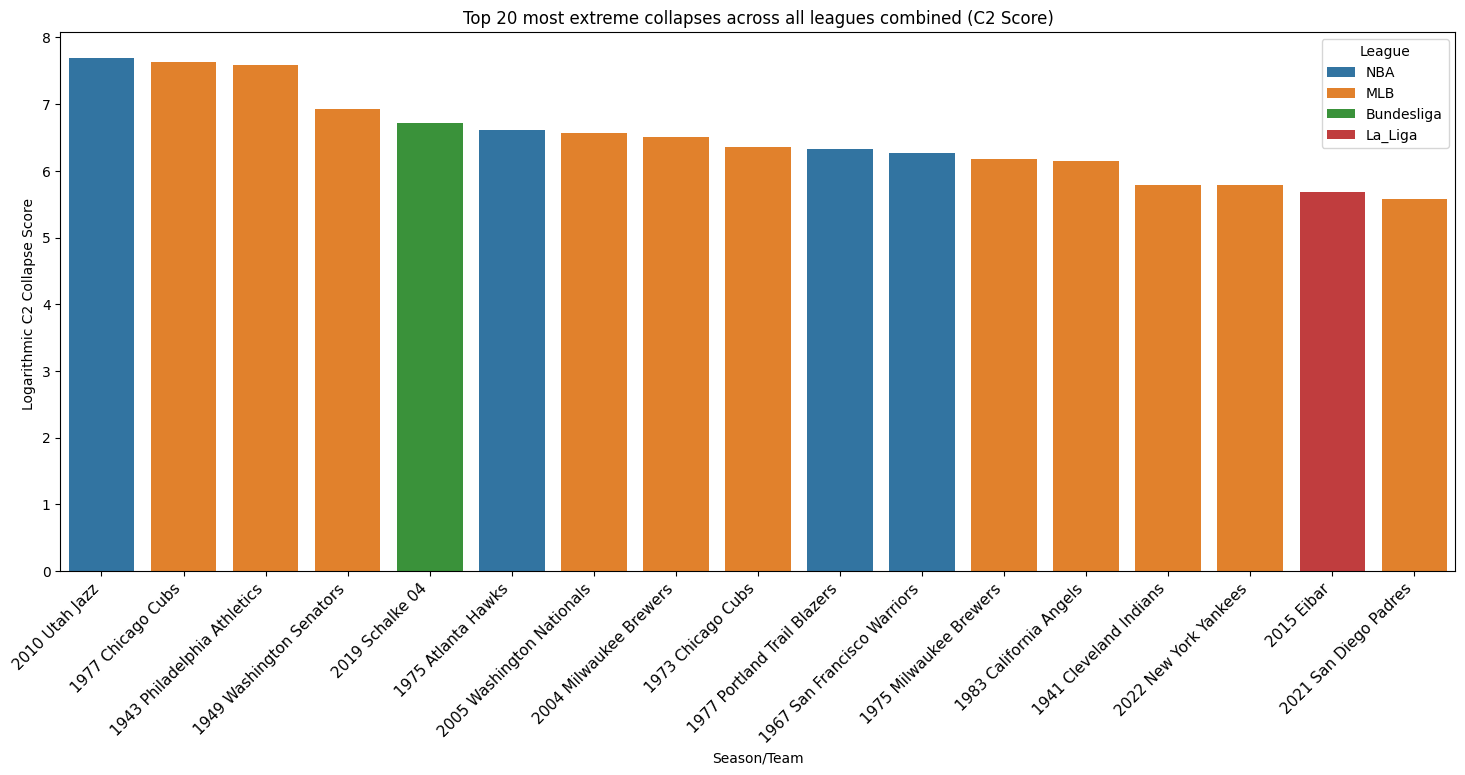

In [63]:
plt.figure(figsize=(18,7))

sns.barplot(x=combined__top20_c2['Team_Name'], y = combined__top20_c2['log_c2'], palette = 'tab10', hue = combined__top20_c2['League'])
plt.title('Top 20 most extreme collapses across all leagues combined (C2 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C2 Collapse Score ')
plt.xticks(rotation=45, fontsize=11, ha='right') 
plt.show()

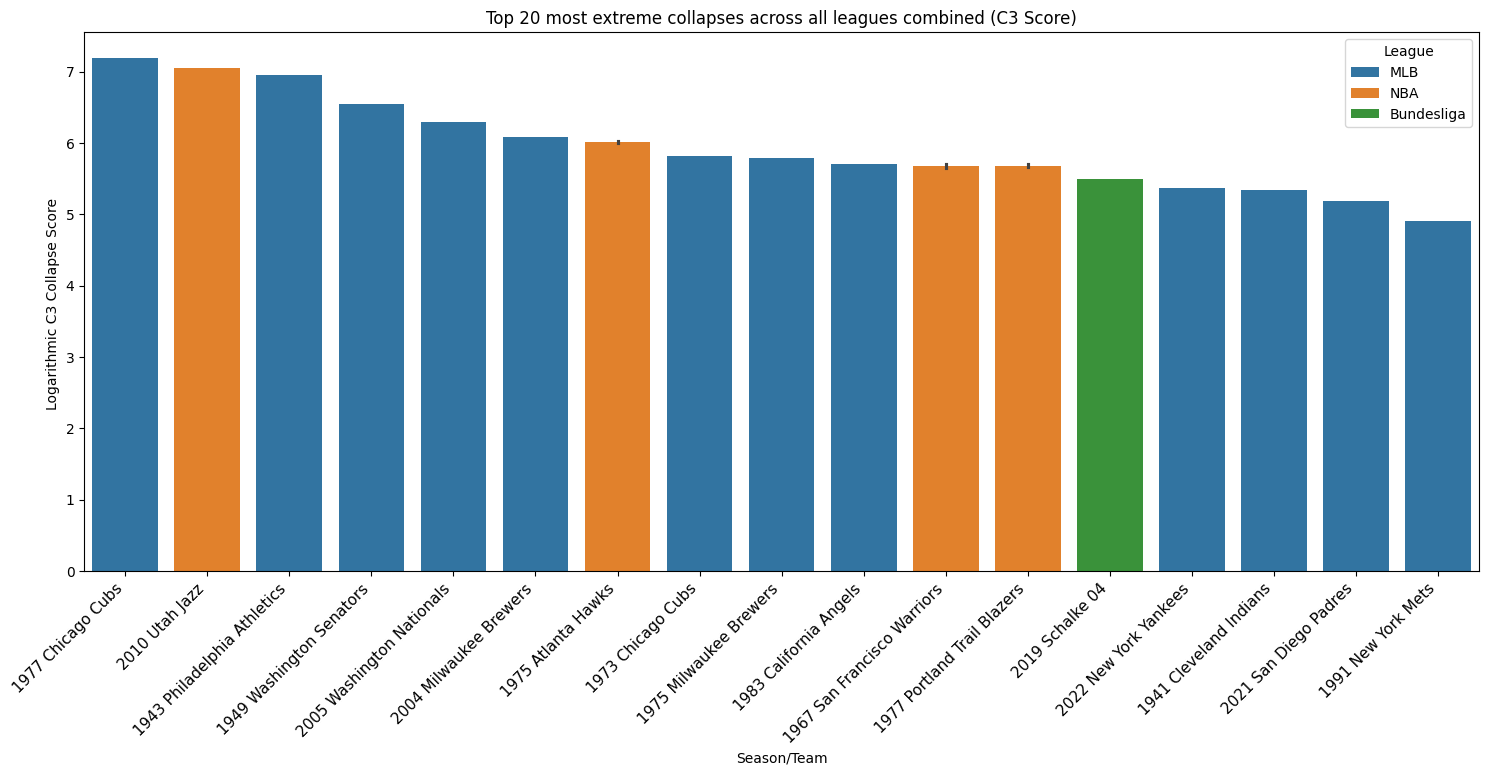

In [64]:
plt.figure(figsize=(18,7))

sns.barplot(x=combined__top20_c3['Team_Name'], y = combined__top20_c3['log_c3'], palette = 'tab10', hue = combined__top20_c3['League'])
plt.title('Top 20 most extreme collapses across all leagues combined (C3 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C3 Collapse Score ')
plt.xticks(rotation=45, fontsize=11, ha='right') 
plt.show()

In [65]:
combined_df.sort_values('c1', ascending = False)

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,Team_Name,log_c1,log_c2,log_c3,formatted_team_name,color
1750,312,MLB,1943,Philadelphia Athletics,"[0,0,1,1,0,0,1,0,0,0,0,1,1,0,1,0,1,0,1,0,1,1,0...",154,77,77,49,34,15,87.788091,1976.242593,1052.631579,1943 Philadelphia Athletics,4.474926,7.588953,6.959049,1943 Philadelphia Athletics,blue
2383,945,MLB,1977,Chicago Cubs,"[0,0,1,1,1,1,0,0,0,0,1,1,1,0,0,0,1,1,0,1,1,1,1...",162,81,81,81,51,30,77.959464,2067.336349,1333.333333,1977 Chicago Cubs,4.356189,7.634016,7.195437,1977 Chicago Cubs,blue
4280,2842,NBA,2010,Utah Jazz,"[0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, ...",82,41,41,39,27,12,75.132853,2197.222917,1162.790698,2010 Utah Jazz,4.319258,7.694950,7.058578,2010 Utah Jazz,orange
1851,413,MLB,1949,Washington Senators,"[1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,1,1,1,1,1,1,1...",154,77,77,50,34,16,60.154303,1025.288429,694.444444,1949 Washington Senators,4.096913,6.932729,6.543112,1949 Washington Senators,blue
5592,4154,NBA,1975,Atlanta Hawks,"[1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, ...",82,41,41,29,21,8,46.612073,747.418894,404.858300,1975 Atlanta Hawks,3.841860,6.616626,6.003537,1975 Atlanta Hawks,orange
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
866,866,Premier_League,2020,Norwich,"[0, 0, 0, 0, 0, 0, 0]",7,4,3,0,0,0,1.000000,NaN,1.000000,2020 Norwich,0.000000,NaN,0.000000,NaN,NaN
1348,1348,La_Liga,2020,Leganes,"[1, 1, 1]",3,2,1,3,2,1,1.000000,NaN,1.000000,2020 Leganes,0.000000,NaN,0.000000,NaN,NaN
1344,1344,La_Liga,2020,Espanol,"[0, 0, 0, 0, 0]",5,3,2,0,0,0,1.000000,NaN,1.000000,2020 Espanol,0.000000,NaN,0.000000,NaN,NaN
343,343,Bundesliga,2019,Bayern Munich,"[1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, ...",30,15,15,26,11,15,1.000000,1.016098,1.000000,2019 Bayern Munich,0.000000,0.015970,0.000000,NaN,NaN


# Top 5 Collapse Scores for Soccer Leagues

## Collapse Score C1

In [66]:
soccer_collapse = combined_df[(combined_df['League']=='Premier_League') | (combined_df['League']=='La_Liga') | (combined_df['League']=='Bundesliga')]
soccer_collapse

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,Team_Name,log_c1,log_c2,log_c3,formatted_team_name,color
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.269036,2000 Bayern Munich,0.346570,0.419869,0.238257,NaN,NaN
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,5.714286,2000 Bochum,1.268947,2.351616,1.742969,NaN,NaN
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.422475,2000 Cottbus,0.431849,0.585585,0.352398,NaN,NaN
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.103753,2000 Dortmund,0.199821,0.214727,0.098716,NaN,NaN
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.469136,2000 Ein Frankfurt,0.823455,1.351674,0.903868,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.731343,2024 Sociedad,1.064602,1.750629,1.316768,NaN,NaN
1434,1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.008065,2024 Valencia,0.030838,0.014233,0.008032,NaN,NaN
1435,1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.290123,2024 Valladolid,2.127773,4.097124,2.959593,NaN,NaN
1436,1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.703578,2024 Vallecano,0.583902,0.858610,0.532730,NaN,NaN


In [67]:
top5_c1 = soccer_collapse.nlargest(5, "log_c1")[["Season", "League", "Team_Name", "log_c1"]]
top5_c2 = soccer_collapse.nlargest(5, "log_c2")[["Season", "League", "Team_Name", "log_c2"]]
top5_c3 = soccer_collapse.nlargest(5, "log_c3")[["Season", "League", "Team_Name", "log_c3"]]

top5_c1

,Season,League,Team_Name,log_c1
356,2019,Bundesliga,2019 Schalke 04,3.633475
1240,2015,La_Liga,2015 Eibar,3.111365
292,2016,Bundesliga,2016 Ein Frankfurt,3.022601
755,2015,Premier_League,2015 Crystal Palace,2.903254
1376,2021,La_Liga,2021 Vallecano,2.903254


In [68]:
top5_c1['Team_Name'] = top5_c1['Team_Name'].replace("2019 Schalke 04", "2019 Schalke")
top5_c1['Team_Name'] = top5_c1['Team_Name'].replace("2016 Ein Frankfurt", "2016 Frankfurt")
top5_c1

,Season,League,Team_Name,log_c1
356,2019,Bundesliga,2019 Schalke,3.633475
1240,2015,La_Liga,2015 Eibar,3.111365
292,2016,Bundesliga,2016 Frankfurt,3.022601
755,2015,Premier_League,2015 Crystal Palace,2.903254
1376,2021,La_Liga,2021 Vallecano,2.903254


In [69]:
top5_c2['Team_Name'] = top5_c2['Team_Name'].replace("2019 Schalke 04", "2019 Schalke")
top5_c2['Team_Name'] = top5_c2['Team_Name'].replace("2016 Ein Frankfurt", "2016 Frankfurt")
top5_c2

,Season,League,Team_Name,log_c2
356,2019,Bundesliga,2019 Schalke,6.724543
1240,2015,La_Liga,2015 Eibar,5.690571
292,2016,Bundesliga,2016 Frankfurt,5.501184
172,2009,Bundesliga,2009 Leverkusen,5.316148
1121,2009,La_Liga,2009 La Coruna,5.307684


In [70]:
top5_c3['Team_Name'] = top5_c3['Team_Name'].replace("2019 Schalke 04", "2019 Schalke")
top5_c3['Team_Name'] = top5_c3['Team_Name'].replace("2016 Ein Frankfurt", "2016 Frankfurt")
top5_c3

,Season,League,Team_Name,log_c3
356,2019,Bundesliga,2019 Schalke,5.501658
1240,2015,La_Liga,2015 Eibar,4.737559
292,2016,Bundesliga,2016 Frankfurt,4.470639
1121,2009,La_Liga,2009 La Coruna,4.374058
755,2015,Premier_League,2015 Crystal Palace,4.250297


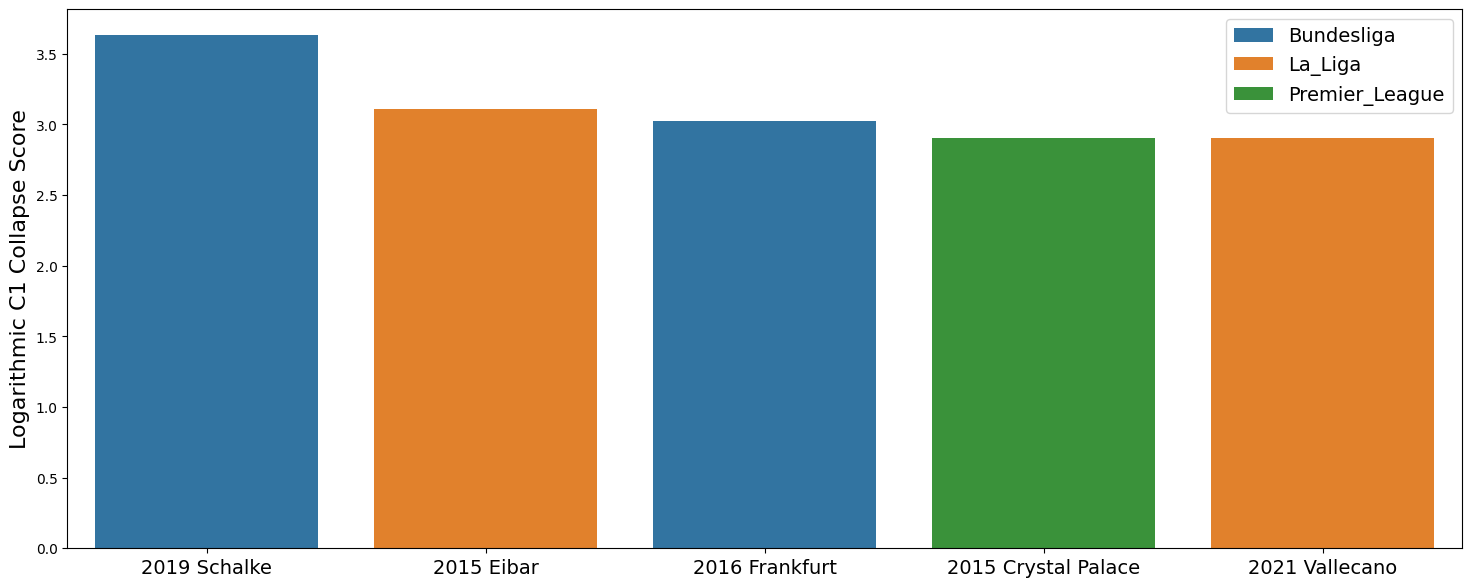

In [71]:
plt.figure(figsize=(18,7))

sns.barplot(x=top5_c1['Team_Name'], y = top5_c1['log_c1'], palette = 'tab10', hue = top5_c1['League'])
plt.xlabel(None)
plt.ylabel('Logarithmic C1 Collapse Score', fontsize=16)
plt.legend(fontsize=14, title_fontsize=15)
plt.xticks(fontsize=14) 
plt.savefig("figures/soccer_top5_c1_collapses.png", dpi=300, bbox_inches='tight') 
plt.show()

## Collapse Score C2

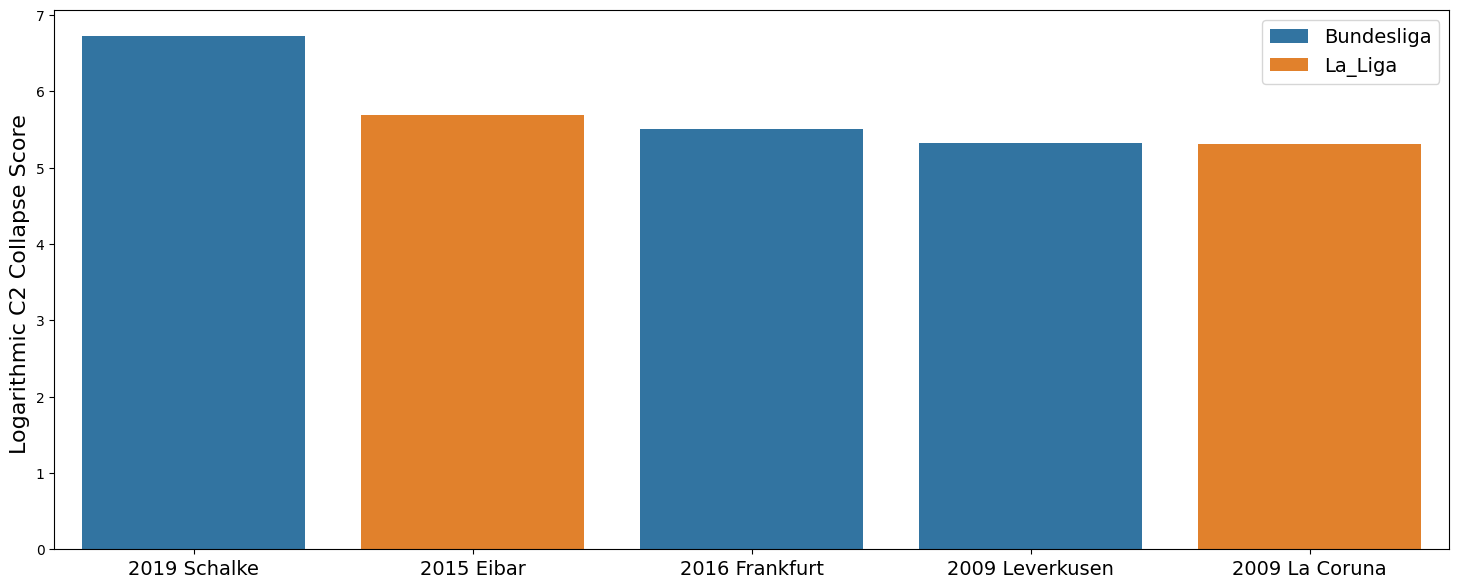

In [72]:
plt.figure(figsize=(18,7))

sns.barplot(x=top5_c2['Team_Name'], y = top5_c2['log_c2'], palette = 'tab10', hue = top5_c2['League'])
plt.xlabel(None)
plt.ylabel('Logarithmic C2 Collapse Score ', fontsize = 16)
plt.legend(fontsize=14, title_fontsize=15)
plt.xticks(fontsize=14) 
plt.savefig("figures/soccer_top5_c2_collapses.png", dpi=300, bbox_inches='tight') 
plt.show()

## Collapse Score C3

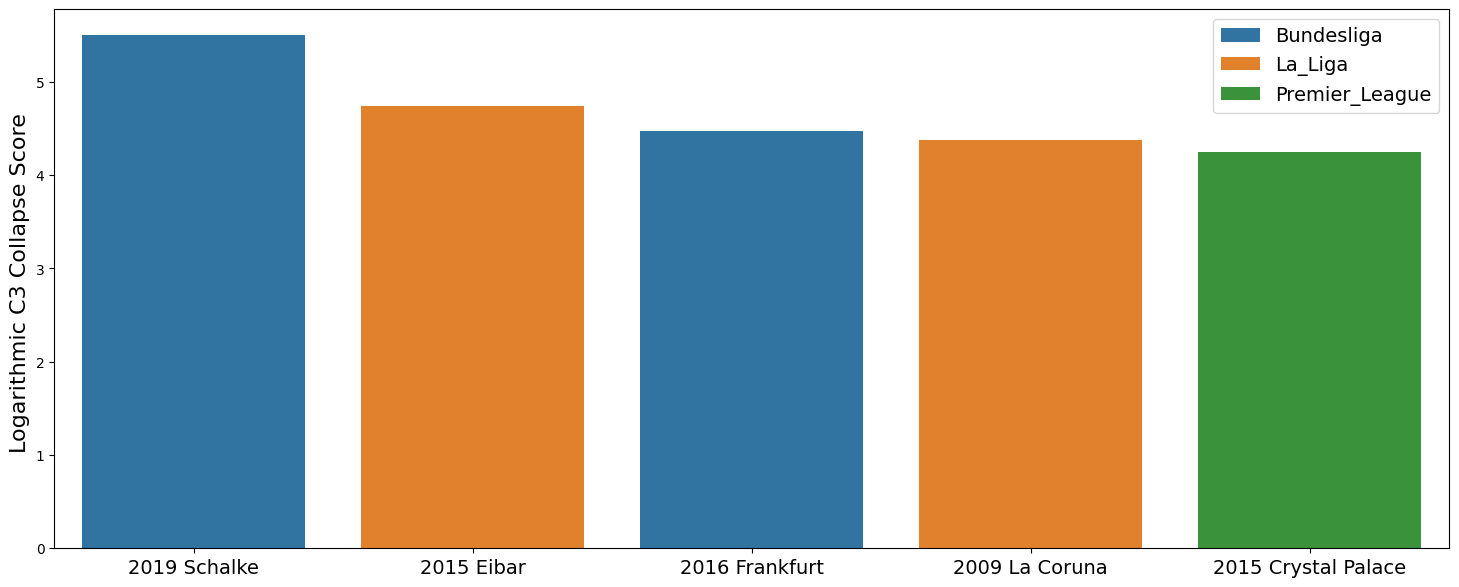

In [73]:
plt.figure(figsize=(18,7))

sns.barplot(x=top5_c3['Team_Name'], y = top5_c3['log_c3'], palette = 'tab10', hue = top5_c3['League'])
plt.xlabel(None)
plt.ylabel('Logarithmic C3 Collapse Score ', fontsize = 16)
plt.legend(fontsize=14, title_fontsize=15)
plt.xticks(fontsize=14) 
plt.savefig("figures/soccer_top5_c3_collapses.png", dpi=300, bbox_inches='tight') 
plt.show()

# Top 5 Collapse Scores for US Leagues

In [74]:
us_collapse = combined_df[(combined_df['League']=='MLB') | (combined_df['League']=='NBA')]
us_collapse

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,Team_Name,log_c1,log_c2,log_c3,formatted_team_name,color
1438,0,NBA,2015,Orlando Magic,"[0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...",82,41,41,35,20,15,3.764011,7.567749,5.494505,2015 Orlando Magic,1.325485,2.023896,1.703749,2015 Orlando Magic,orange
1439,1,NBA,2015,Houston Rockets,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...",82,41,41,41,21,20,2.000000,2.423658,1.934236,2015 Houston Rockets,0.693147,0.885278,0.659712,2015 Houston Rockets,orange
1440,2,NBA,2015,Oklahoma City Thunder,"[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, ...",82,41,41,55,29,26,2.749747,4.159434,3.030303,2015 Oklahoma City Thunder,1.011509,1.425379,1.108663,2015 Oklahoma City Thunder,orange
1441,3,NBA,2015,Sacramento Kings,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,18,15,2.639310,4.005520,3.030303,2015 Sacramento Kings,0.970518,1.387673,1.108663,2015 Sacramento Kings,orange
1442,4,NBA,2015,Utah Jazz,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, ...",82,41,41,40,18,22,1.277825,1.232172,1.172333,2015 Utah Jazz,0.245159,0.208778,0.158996,2015 Utah Jazz,orange
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5756,4318,NBA,1982,Indiana Pacers,"[1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...",82,41,41,20,13,7,5.464184,16.280440,9.803922,1982 Indiana Pacers,1.698215,2.789964,2.282782,1982 Indiana Pacers,orange
5757,4319,NBA,1982,Washington Bullets,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",82,41,41,42,18,24,1.158671,1.101917,1.057082,1982 Washington Bullets,0.147274,0.097051,0.055513,1982 Washington Bullets,orange
5758,4320,NBA,1982,Dallas Mavericks,"[1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, ...",82,41,41,38,19,19,1.774389,2.000000,1.672241,1982 Dallas Mavericks,0.573456,0.693147,0.514165,1982 Dallas Mavericks,orange
5759,4321,NBA,1982,Denver Nuggets,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,45,19,26,1.115894,1.064008,1.041667,1982 Denver Nuggets,0.109655,0.062043,0.040822,1982 Denver Nuggets,orange


In [75]:
us_top5_c1 = us_collapse.nlargest(5, "log_c1")[["Season", "League", "Team_Name", "log_c1"]]
us_top5_c2 = us_collapse.nlargest(5, "log_c2")[["Season", "League", "Team_Name", "log_c2"]]
us_top5_c3 = us_collapse.nlargest(5, "log_c3")[["Season", "League", "Team_Name", "log_c3"]]

us_top5_c1

,Season,League,Team_Name,log_c1
1750,1943,MLB,1943 Philadelphia Athletics,4.474926
2383,1977,MLB,1977 Chicago Cubs,4.356189
4280,2010,NBA,2010 Utah Jazz,4.319258
1851,1949,MLB,1949 Washington Senators,4.096913
5180,1975,NBA,1975 Atlanta Hawks,3.841860


## Collapse Score C1

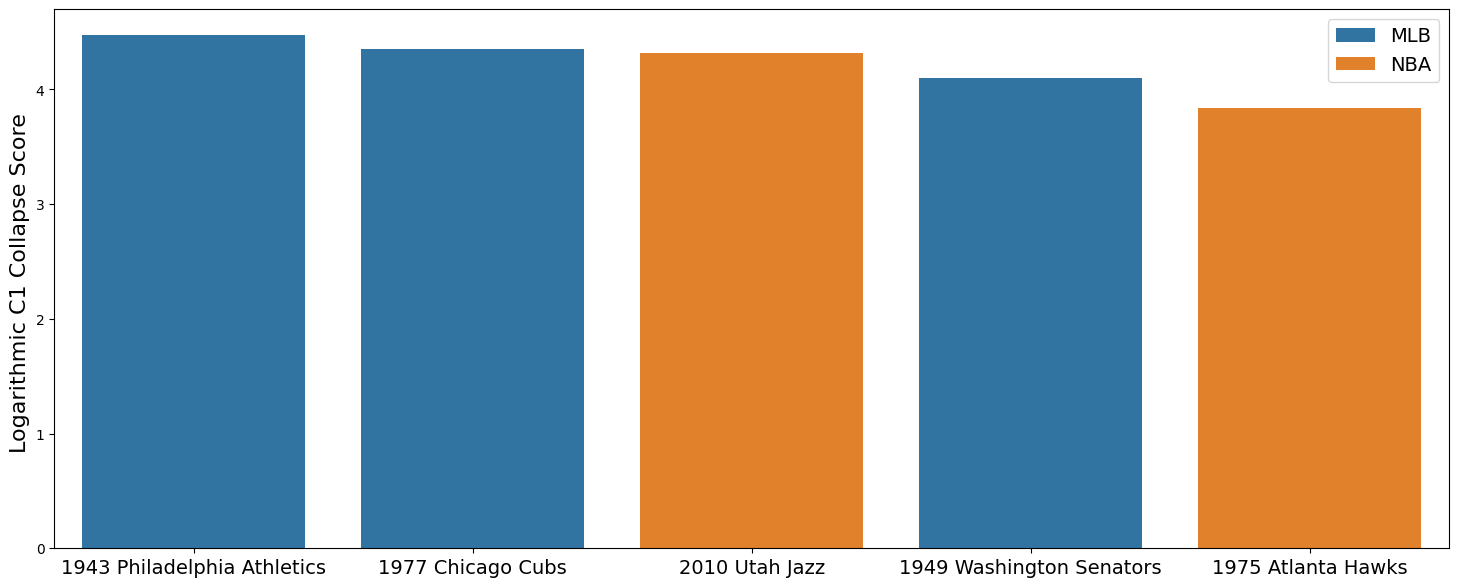

In [76]:
tab10 = sns.color_palette("tab10")

us_leagues_palette = {"NBA": tab10[1],  "MLB": tab10[0]}

plt.figure(figsize=(18,7))
sns.barplot(x=us_top5_c1['Team_Name'], y = us_top5_c1['log_c1'], palette = us_leagues_palette, hue = us_top5_c1['League'],hue_order=["MLB", "NBA"])
plt.xlabel(None)
plt.ylabel('Logarithmic C1 Collapse Score ', fontsize = 16)
plt.legend(fontsize=14, title_fontsize=15)
plt.xticks(fontsize=14) 
plt.savefig("figures/us_top5_c1_collapse.png", dpi=300, bbox_inches='tight') 
plt.show()


## Collapse Score C2

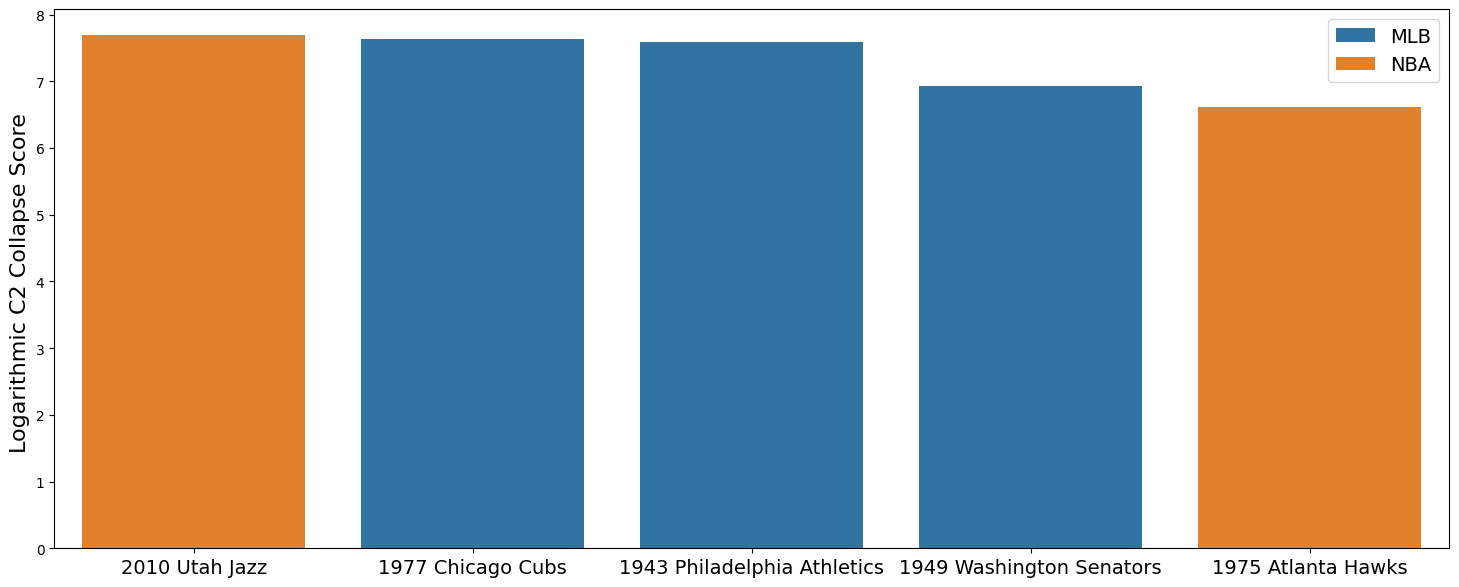

In [77]:
tab10 = sns.color_palette("tab10")

us_leagues_palette = {"NBA": tab10[1],  "MLB": tab10[0]}

plt.figure(figsize=(18,7))
sns.barplot(x=us_top5_c2['Team_Name'], y = us_top5_c2['log_c2'], palette = us_leagues_palette, hue = us_top5_c2['League'], hue_order=["MLB", "NBA"])
plt.xlabel(None)
plt.ylabel('Logarithmic C2 Collapse Score ', fontsize = 16)
plt.legend(fontsize=14, title_fontsize=15)
plt.xticks(fontsize=14) 
plt.savefig("figures/us_top5_c2_collapse.png", dpi=300, bbox_inches='tight') 
plt.show()

## Collapse Score C3

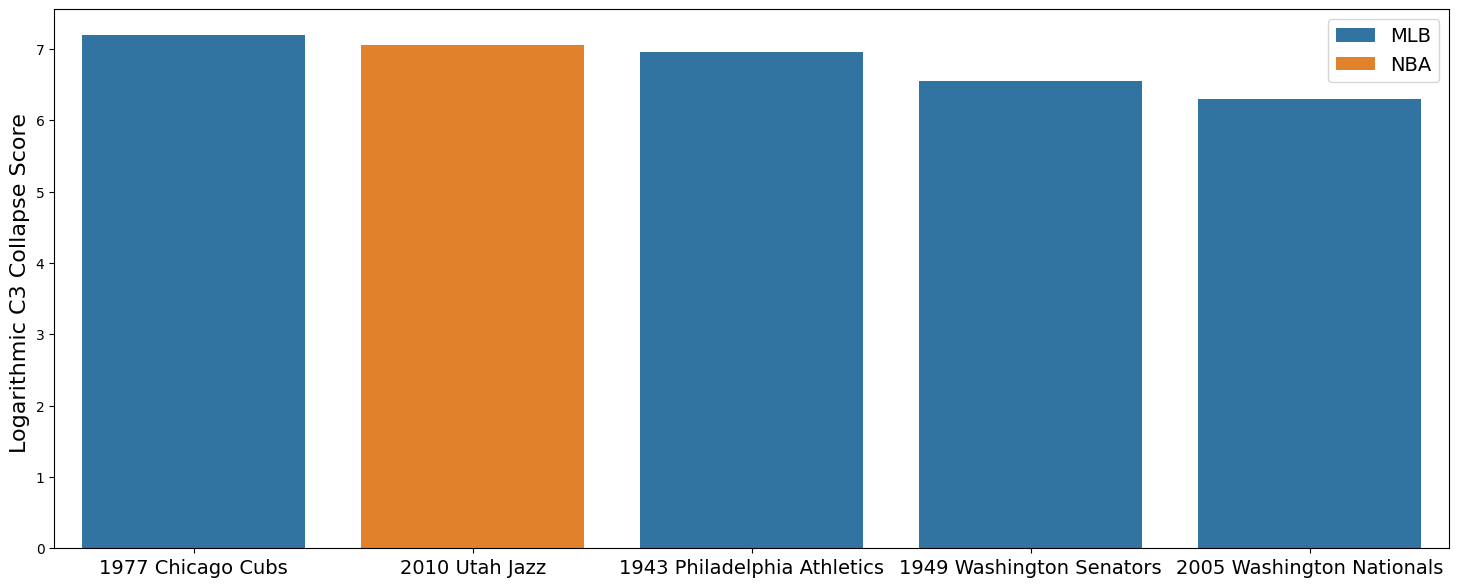

In [78]:
tab10 = sns.color_palette("tab10")

us_leagues_palette = {"NBA": tab10[1],  "MLB": tab10[0]}


plt.figure(figsize=(18,7))

sns.barplot(x=us_top5_c3['Team_Name'], y = us_top5_c3['log_c3'], palette = us_leagues_palette, hue = us_top5_c3['League'], hue_order=["MLB", "NBA"])
plt.xlabel(None)
plt.ylabel('Logarithmic C3 Collapse Score ', fontsize = 16)
plt.legend(fontsize=14, title_fontsize=15)
plt.xticks(fontsize=14) 
plt.savefig("figures/us_top5_c3_collapse.png", dpi=300, bbox_inches='tight') 
plt.show()